In [6]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import umap
from datasets import load_dataset
import pacmap
import random
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("Qwen/Qwen3-Embedding-0.6B")
ds = load_dataset("qwedsacf/competition_math")

In [20]:
indices = random.sample(range(len(ds['train'])), 99)

texts = [ds['train']['problem'][i] for i in indices]
colors_type = [ds['train']['type'][i] for i in indices]
colors_level = [ds['train']['level'][i] for i in indices]

In [21]:
embeddings_matrix = model.encode(texts)

similarities = model.similarity(embeddings_matrix, embeddings_matrix)
print(similarities.shape)

KeyboardInterrupt: 

### UMAP

In [ ]:
unique_types = list(set(colors_level)) # colors_level # colors_type
color_map = {type_name: i for i, type_name in enumerate(unique_types)}
color_values = [color_map[c] for c in colors_level] # colors_level # colors_type

/Users/shreyanakum/Documents/knowledge-gaps/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


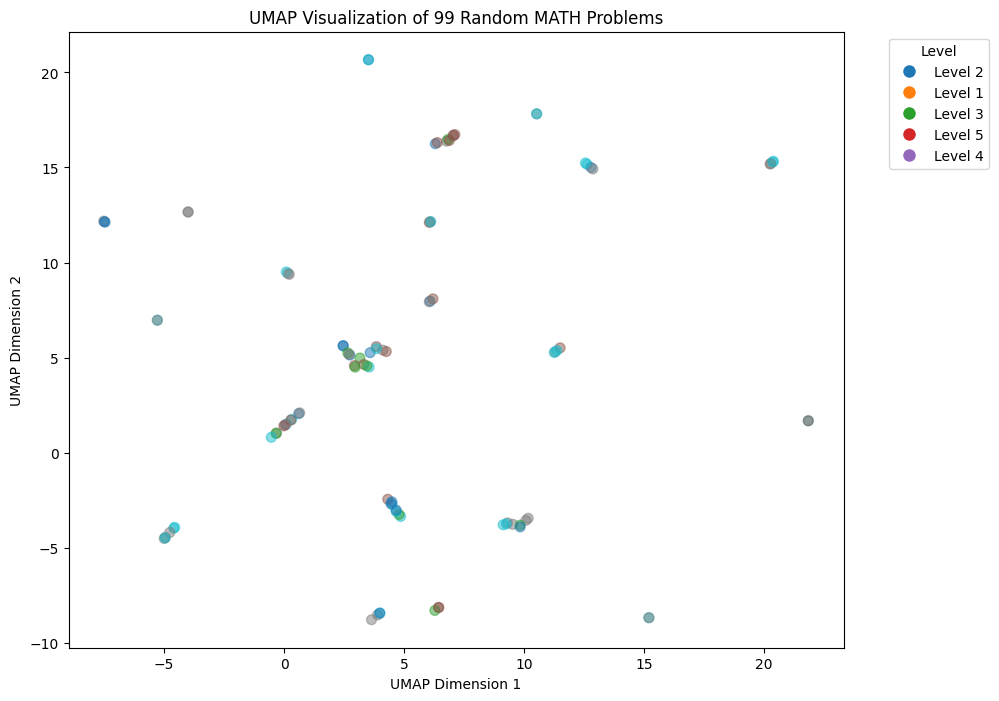

In [ ]:
reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=2, min_dist=0.1, init='random')
embeddings_2d = reducer.fit_transform(embeddings_matrix)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=color_values, s=50, alpha=0.5, cmap='tab10')

for i, txt in enumerate(texts):
    plt.annotate(txt[:0], (embeddings_2d[i, 0], embeddings_2d[i, 1]))

plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
plt.title('UMAP Visualization of 99 Random MATH Problems')
handles = [plt.Line2D([0], [0], marker='o', color='w', 
                      markerfacecolor=plt.cm.tab10(color_map[t]), 
                      markersize=10, label=t) 
           for t in unique_types]
plt.legend(handles=handles, title='Level', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.savefig("./umap_colors_level.png")

### PaCMAP

In [11]:
np.shape(embeddings_matrix)

(99, 1024)

In [12]:
# initializing the pacmap instance
# Setting n_neighbors to "None" leads to an automatic choice shown below in "parameter" section
embedding = pacmap.PaCMAP(n_components=2, n_neighbors=10, MN_ratio=0.5, FP_ratio=2.0) 

X = embeddings_matrix.reshape(embeddings_matrix.shape[0], -1)

# fit the data (The index of transformed data corresponds to the index of the original data)
X_transformed = embedding.fit_transform(X, init="pca")

# visualize the embedding
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.scatter(X_transformed[:, 0], X_transformed[:, 1], cmap="Spectral", s=20)

ValueError: could not broadcast input array from shape (0,) into shape (60,)